# BLA Frequency-Domain Band Ratio Graphs

This notebook uses the same overall method as your global-baseline frequency-domain notebook, but instead of graphing individual band power, it graphs **ratios between pairs of frequency bands**.

For each subject:

1. Load the same BLA epochs.
2. Optionally crop to a specific time window.
3. Compute frequency-domain absolute power with `compute_frequency_power()`.
4. Convert the output into a trial × band table.
5. Compute ratios such as `theta / delta`, `alpha / theta`, or `gamma / beta`.
6. Center each ratio by subtracting that subject's across-trial mean ratio.
7. Grand-average the centered ratio values across subjects.
8. Plot trial-by-trial ratio changes with SEM and a rolling mean.

The ratio pairs are editable in the setup cell.


In [1]:

# NumPy handles arrays, indexing, and mathematical operations.
import numpy as np

# Pandas stores trial-by-band tables and makes averaging easier.
import pandas as pd

# Matplotlib is used to make the figures.
import matplotlib.pyplot as plt

# These imports let us silence extra warnings / printouts from the helper functions.
import warnings
import contextlib
import io

# These project helper functions are already used elsewhere in your notebook.
# - load_eeg_data loads the epochs for one subject
# - compute_frequency_power computes frequency-domain band power per trial
from utils import load_eeg_data, compute_frequency_power

# Show plots directly inside the notebook.
%matplotlib inline

# Slightly increase default display quality so the plots are easier to read.
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


In [2]:

# These are the subjects used in your BLA analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
CONDITION = "BLA"

# CHANNELS tells the loader to use the BLA ROI channel group.
CHANNELS = "BLA"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")


# ------------------------------------------------------------
# BAND RATIO SETTINGS
# ------------------------------------------------------------

# Each tuple is written as:
#     ('numerator_band', 'denominator_band')
#
# Example:
#     ('theta', 'alpha') means theta power divided by alpha power.
#
# You can edit this list if you want different pairs.
BAND_RATIO_PAIRS = [
    ('theta', 'delta'),
    ('alpha', 'theta'),
    ('beta', 'alpha'),
    ('gamma', 'beta'),
    ('theta', 'beta'),
    ('gamma', 'theta'),
    ('gamma', 'alpha')
]

# These labels will be used on the plots.
ratio_labels = [f"{num}/{den}" for num, den in BAND_RATIO_PAIRS]

# Colors for ratio plots. If there are more ratios than colors, the list repeats.
ratio_colors = [
    'blue',
    'green',
    'red',
    'orange',
    'purple',
    'brown',
    'pink',
    'gray',
    'olive',
    'cyan'
]

print("Band ratio pairs:")
for pair in BAND_RATIO_PAIRS:
    print(f"  {pair[0]} / {pair[1]}")


Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLA
Channels: BLA
Baseline definition: global average over all times and all trials
Band ratio pairs:
  theta / delta
  alpha / theta
  beta / alpha
  gamma / beta
  theta / beta
  gamma / theta
  gamma / alpha


In [3]:

# ------------------------------------------------------------
# HELPER FUNCTION: COMPUTE CENTERED BAND RATIOS
# ------------------------------------------------------------

def compute_centered_band_ratios_for_window(window_name, tmin=None, tmax=None):
    """
    Computes centered frequency-band ratios for one time window.

    Parameters
    ----------
    window_name : str
        Text label for the window, such as "all_times", "0_500", or "500_1000".

    tmin : float or None
        Start time in seconds.
        Use None to keep the original beginning of the epoch.

    tmax : float or None
        End time in seconds.
        Use None to keep the original end of the epoch.

    Returns
    -------
    results : dict
        A dictionary containing raw ratio tables, baseline ratio tables,
        centered ratio tables, grand averages, SEMs, processed subjects,
        and failed subjects.
    """

    # These dictionaries store subject-level results.
    all_power_pivots_raw = {}
    all_ratio_pivots_raw = {}
    all_ratio_baseline_pivots = {}
    all_ratio_pivots_centered = {}
    all_psds_dicts = {}

    processed_subjects_window = []
    failed_subjects_window = []

    # Loop through each subject.
    for subject_id in SUBJECTS:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                    # Load the same BLA epochs as the original notebook.
                    epochs = load_eeg_data(
                        CONDITION,
                        subject_id,
                        channels=CHANNELS,
                        freq_band="delta_gamma"
                    )

                    # Crop only if a time window was given.
                    # MNE uses seconds, so:
                    #   0–500 ms      = tmin=0.0, tmax=0.5
                    #   500–1000 ms   = tmin=0.5, tmax=1.0
                    if tmin is not None or tmax is not None:
                        epochs_for_ratio = epochs.copy().crop(tmin=tmin, tmax=tmax)
                    else:
                        epochs_for_ratio = epochs.copy()

                    # Compute frequency-domain absolute power using the same helper function.
                    power_df, psds_dict = compute_frequency_power(
                        epochs_for_ratio,
                        fmin=0.5,
                        fmax=45
                    )

            # Convert long-format power output into trial x band format.
            power_pivot_raw = (
                power_df.groupby(['trial', 'band'])['power']
                .mean()
                .unstack()
                .reindex(columns=bands)
            )

            # This table will hold ratio values for each trial.
            ratio_pivot_raw = pd.DataFrame(index=power_pivot_raw.index)

            # Compute each requested band ratio.
            for numerator_band, denominator_band in BAND_RATIO_PAIRS:

                ratio_name = f"{numerator_band}/{denominator_band}"

                # Make sure both bands exist before computing the ratio.
                if numerator_band in power_pivot_raw.columns and denominator_band in power_pivot_raw.columns:

                    # Ratio = power in numerator band / power in denominator band.
                    ratio_pivot_raw[ratio_name] = (
                        power_pivot_raw[numerator_band] / power_pivot_raw[denominator_band]
                    )

                else:
                    # If a band is missing, fill with NaN so the notebook does not crash.
                    ratio_pivot_raw[ratio_name] = np.nan

            # Replace infinite values with NaN, just in case a denominator is zero.
            ratio_pivot_raw = ratio_pivot_raw.replace([np.inf, -np.inf], np.nan)

            # Compute this subject's global mean ratio across all trials.
            ratio_global_baseline = ratio_pivot_raw.mean(axis=0)

            # Center each trial by subtracting this subject's global mean ratio.
            ratio_pivot_centered = ratio_pivot_raw - ratio_global_baseline

            # Store subject-level outputs.
            all_power_pivots_raw[subject_id] = power_pivot_raw
            all_ratio_pivots_raw[subject_id] = ratio_pivot_raw
            all_ratio_baseline_pivots[subject_id] = pd.DataFrame(
                [ratio_global_baseline],
                columns=ratio_pivot_raw.columns
            )
            all_ratio_pivots_centered[subject_id] = ratio_pivot_centered
            all_psds_dicts[subject_id] = psds_dict

            processed_subjects_window.append(subject_id)

        except Exception as e:
            failed_subjects_window.append((subject_id, str(e)))

    print(f"{window_name} ratio subjects processed:", processed_subjects_window)

    if failed_subjects_window:
        print(f"\n{window_name} ratio failures:")
        for subject_id, err in failed_subjects_window:
            print(f"Subject {subject_id}: {err}")

    # Grand average across subjects.
    grand_ratio = {}
    grand_ratio_sem = {}

    for ratio_name in ratio_labels:
        ratio_trials = []

        for subject_id in processed_subjects_window:
            ratio_pivot = all_ratio_pivots_centered[subject_id]

            if ratio_name in ratio_pivot.columns:
                ratio_trials.append(ratio_pivot[ratio_name].reset_index(drop=True))

        if ratio_trials:
            ratio_df = pd.concat(ratio_trials, axis=1)

            # Mean across subjects at each trial index.
            grand_ratio[ratio_name] = ratio_df.mean(axis=1)

            # SEM across subjects at each trial index.
            grand_ratio_sem[ratio_name] = ratio_df.std(axis=1) / np.sqrt(ratio_df.shape[1])

    return {
        "window_name": window_name,
        "tmin": tmin,
        "tmax": tmax,
        "all_power_pivots_raw": all_power_pivots_raw,
        "all_ratio_pivots_raw": all_ratio_pivots_raw,
        "all_ratio_baseline_pivots": all_ratio_baseline_pivots,
        "all_ratio_pivots_centered": all_ratio_pivots_centered,
        "all_psds_dicts": all_psds_dicts,
        "processed_subjects": processed_subjects_window,
        "failed_subjects": failed_subjects_window,
        "grand_ratio": grand_ratio,
        "grand_ratio_sem": grand_ratio_sem
    }


# ------------------------------------------------------------
# HELPER FUNCTION: PLOT CENTERED BAND RATIOS
# ------------------------------------------------------------

def plot_centered_band_ratios(results, title_label, save_filename):
    """
    Plots the grand-average centered ratio values for one time window.

    Parameters
    ----------
    results : dict
        Output from compute_centered_band_ratios_for_window().

    title_label : str
        Label used in the graph title, such as "All Times" or "0–500 ms".

    save_filename : str
        Name of the saved PNG file.
    """

    grand_ratio = results["grand_ratio"]
    grand_ratio_sem = results["grand_ratio_sem"]

    # Create one subplot per ratio.
    fig, axes = plt.subplots(len(ratio_labels), 1, figsize=(12, 2.5 * len(ratio_labels)), sharex=True)

    # If there is only one ratio, axes is not automatically a list.
    # This forces it to act like a list so the loop below still works.
    if len(ratio_labels) == 1:
        axes = [axes]

    for i, ratio_name in enumerate(ratio_labels):
        ax = axes[i]
        color = ratio_colors[i % len(ratio_colors)]

        if ratio_name in grand_ratio:
            values = grand_ratio[ratio_name].values
            errors = grand_ratio_sem[ratio_name].values
            trial_idx = np.arange(1, len(values) + 1)

            ax.scatter(
                trial_idx,
                values,
                color=color,
                s=20,
                alpha=0.55,
                zorder=2,
                label='Trial value'
            )

            ax.plot(
                trial_idx,
                values,
                color=color,
                linewidth=0.7,
                alpha=0.35,
                zorder=1
            )

            ax.fill_between(
                trial_idx,
                values - errors,
                values + errors,
                color=color,
                alpha=0.18,
                zorder=1,
                label='± SEM'
            )

            rolling = pd.Series(values).rolling(
                window=ROLLING_WINDOW,
                center=True,
                min_periods=1
            ).mean()

            ax.plot(
                trial_idx,
                rolling,
                color='black',
                linewidth=2.5,
                zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})'
            )

        ax.set_ylabel('Ratio minus\nglobal mean', fontsize=10)

        ax.set_title(
            f'ROI average — {ratio_name} ratio, {title_label}',
            fontsize=10,
            fontweight='bold'
        )

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.25)
        ax.legend(loc='upper right', fontsize=8)

    axes[-1].set_xlabel('Trial index', fontsize=11)

    fig.suptitle(
        f'BLA Protocol — Grand Average Frequency-Domain Band Ratios, {title_label}\n'
        f'Centered to subject-level global ratio average',
        fontsize=12,
        fontweight='bold'
    )

    fig.tight_layout()
    plt.savefig(save_filename, bbox_inches='tight', dpi=150)
    plt.show()

    print(f"Figure saved: {save_filename}")


all_times ratio subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


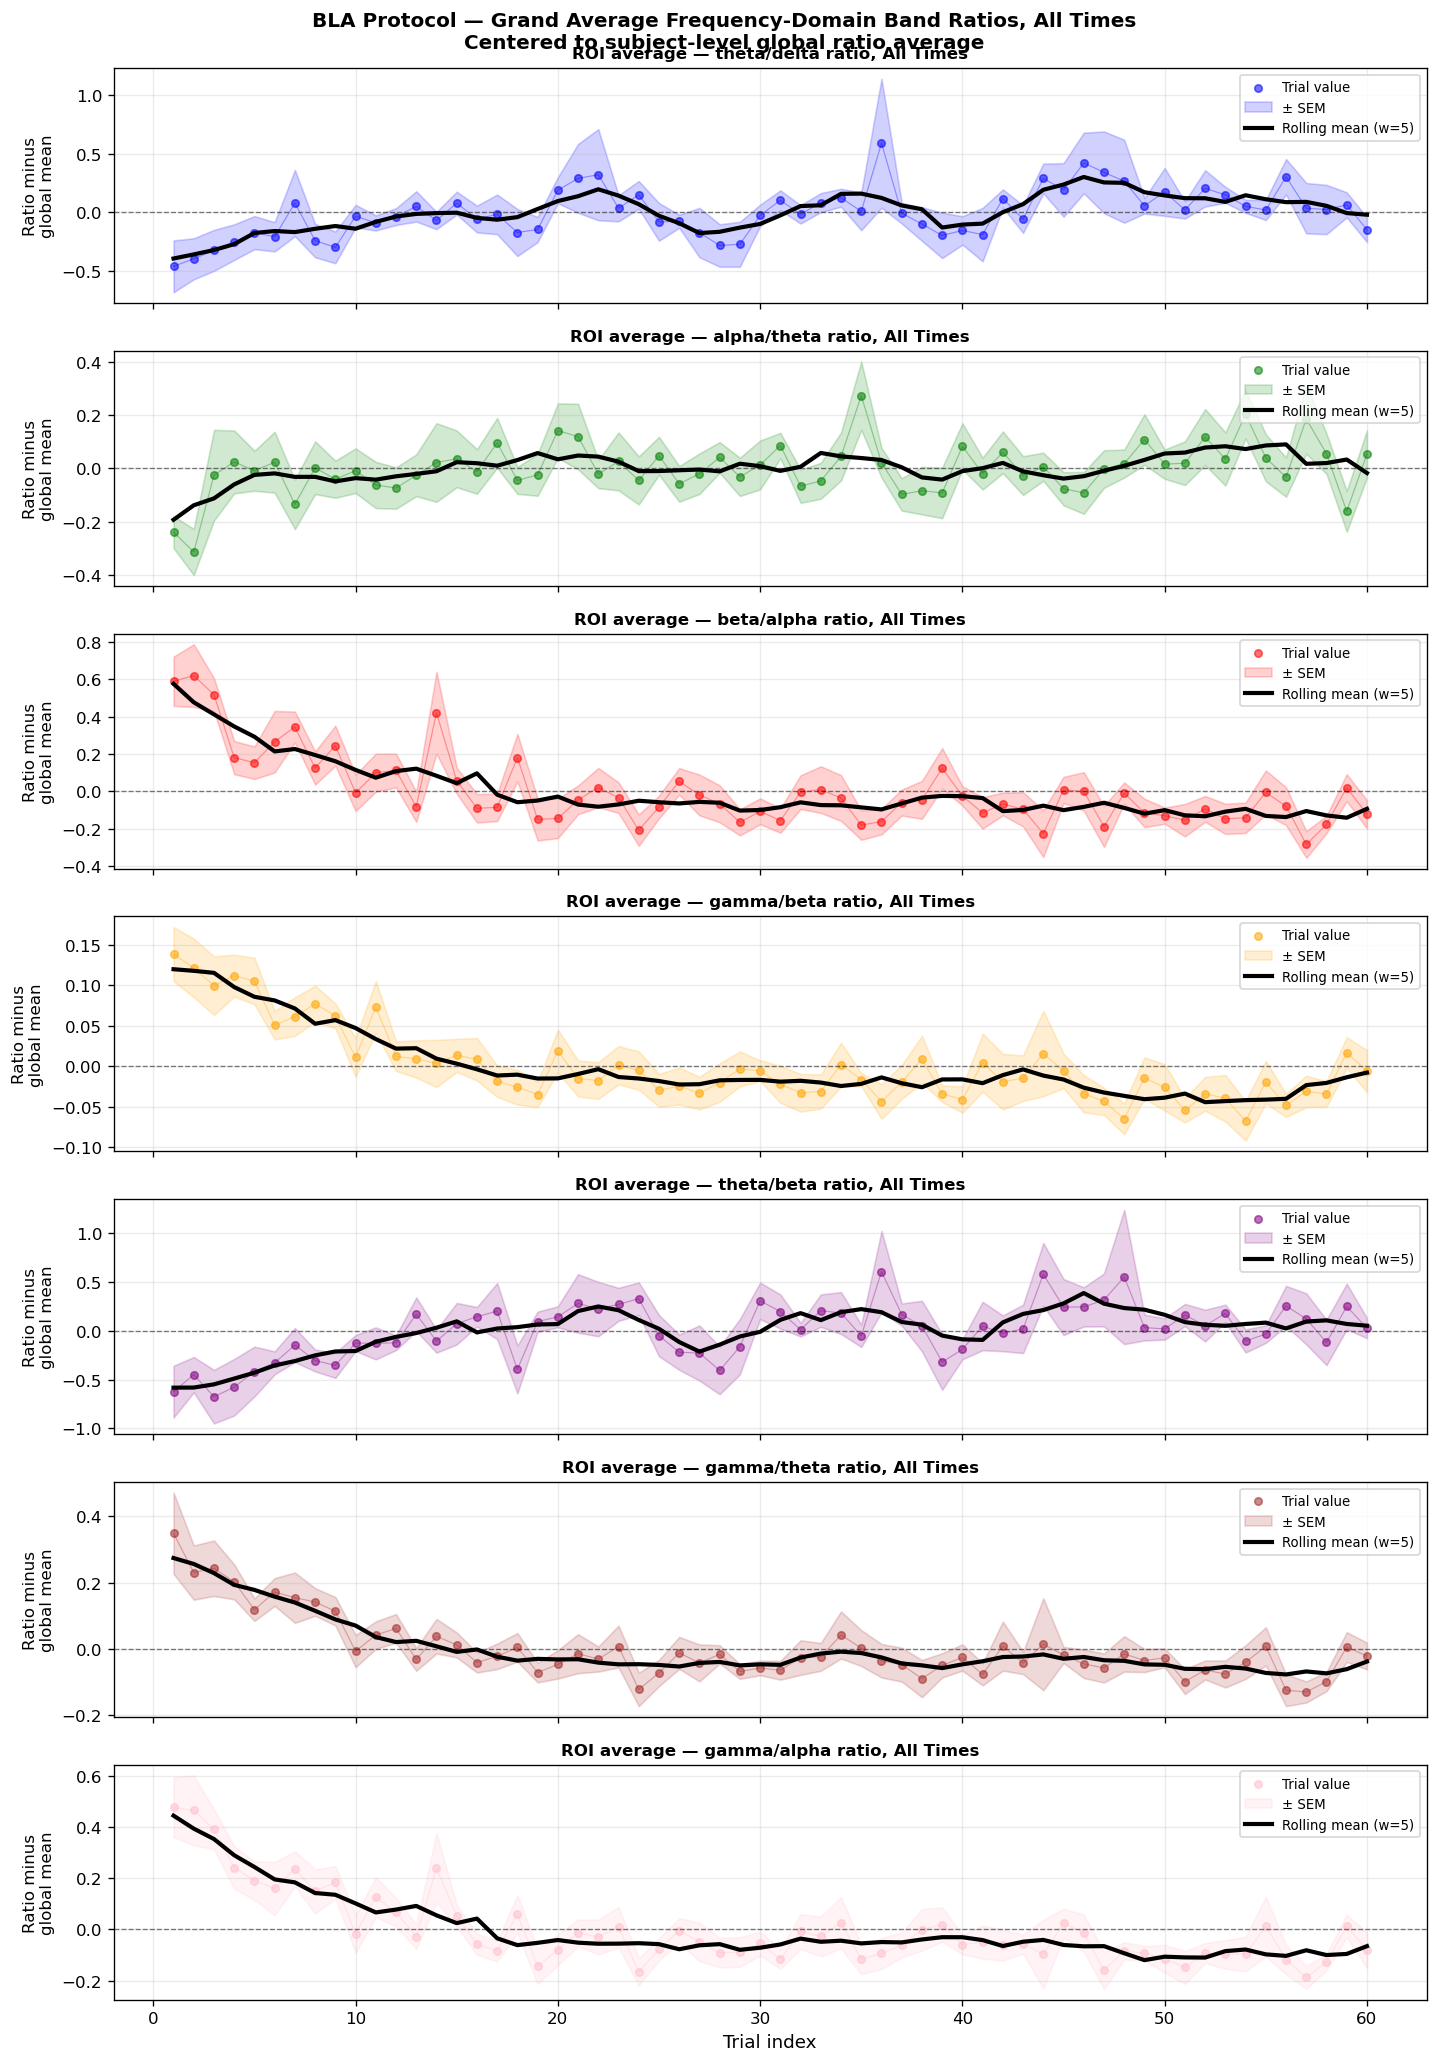

Figure saved: BLA_band_ratios_all_times_global_mean_centered.png


In [4]:

# ------------------------------------------------------------
# BAND RATIOS — ALL TIMES
# ------------------------------------------------------------

ratio_results_all_times = compute_centered_band_ratios_for_window(
    window_name="all_times",
    tmin=None,
    tmax=None
)

plot_centered_band_ratios(
    results=ratio_results_all_times,
    title_label="All Times",
    save_filename="BLA_band_ratios_all_times_global_mean_centered.png"
)


0_500_ms ratio subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


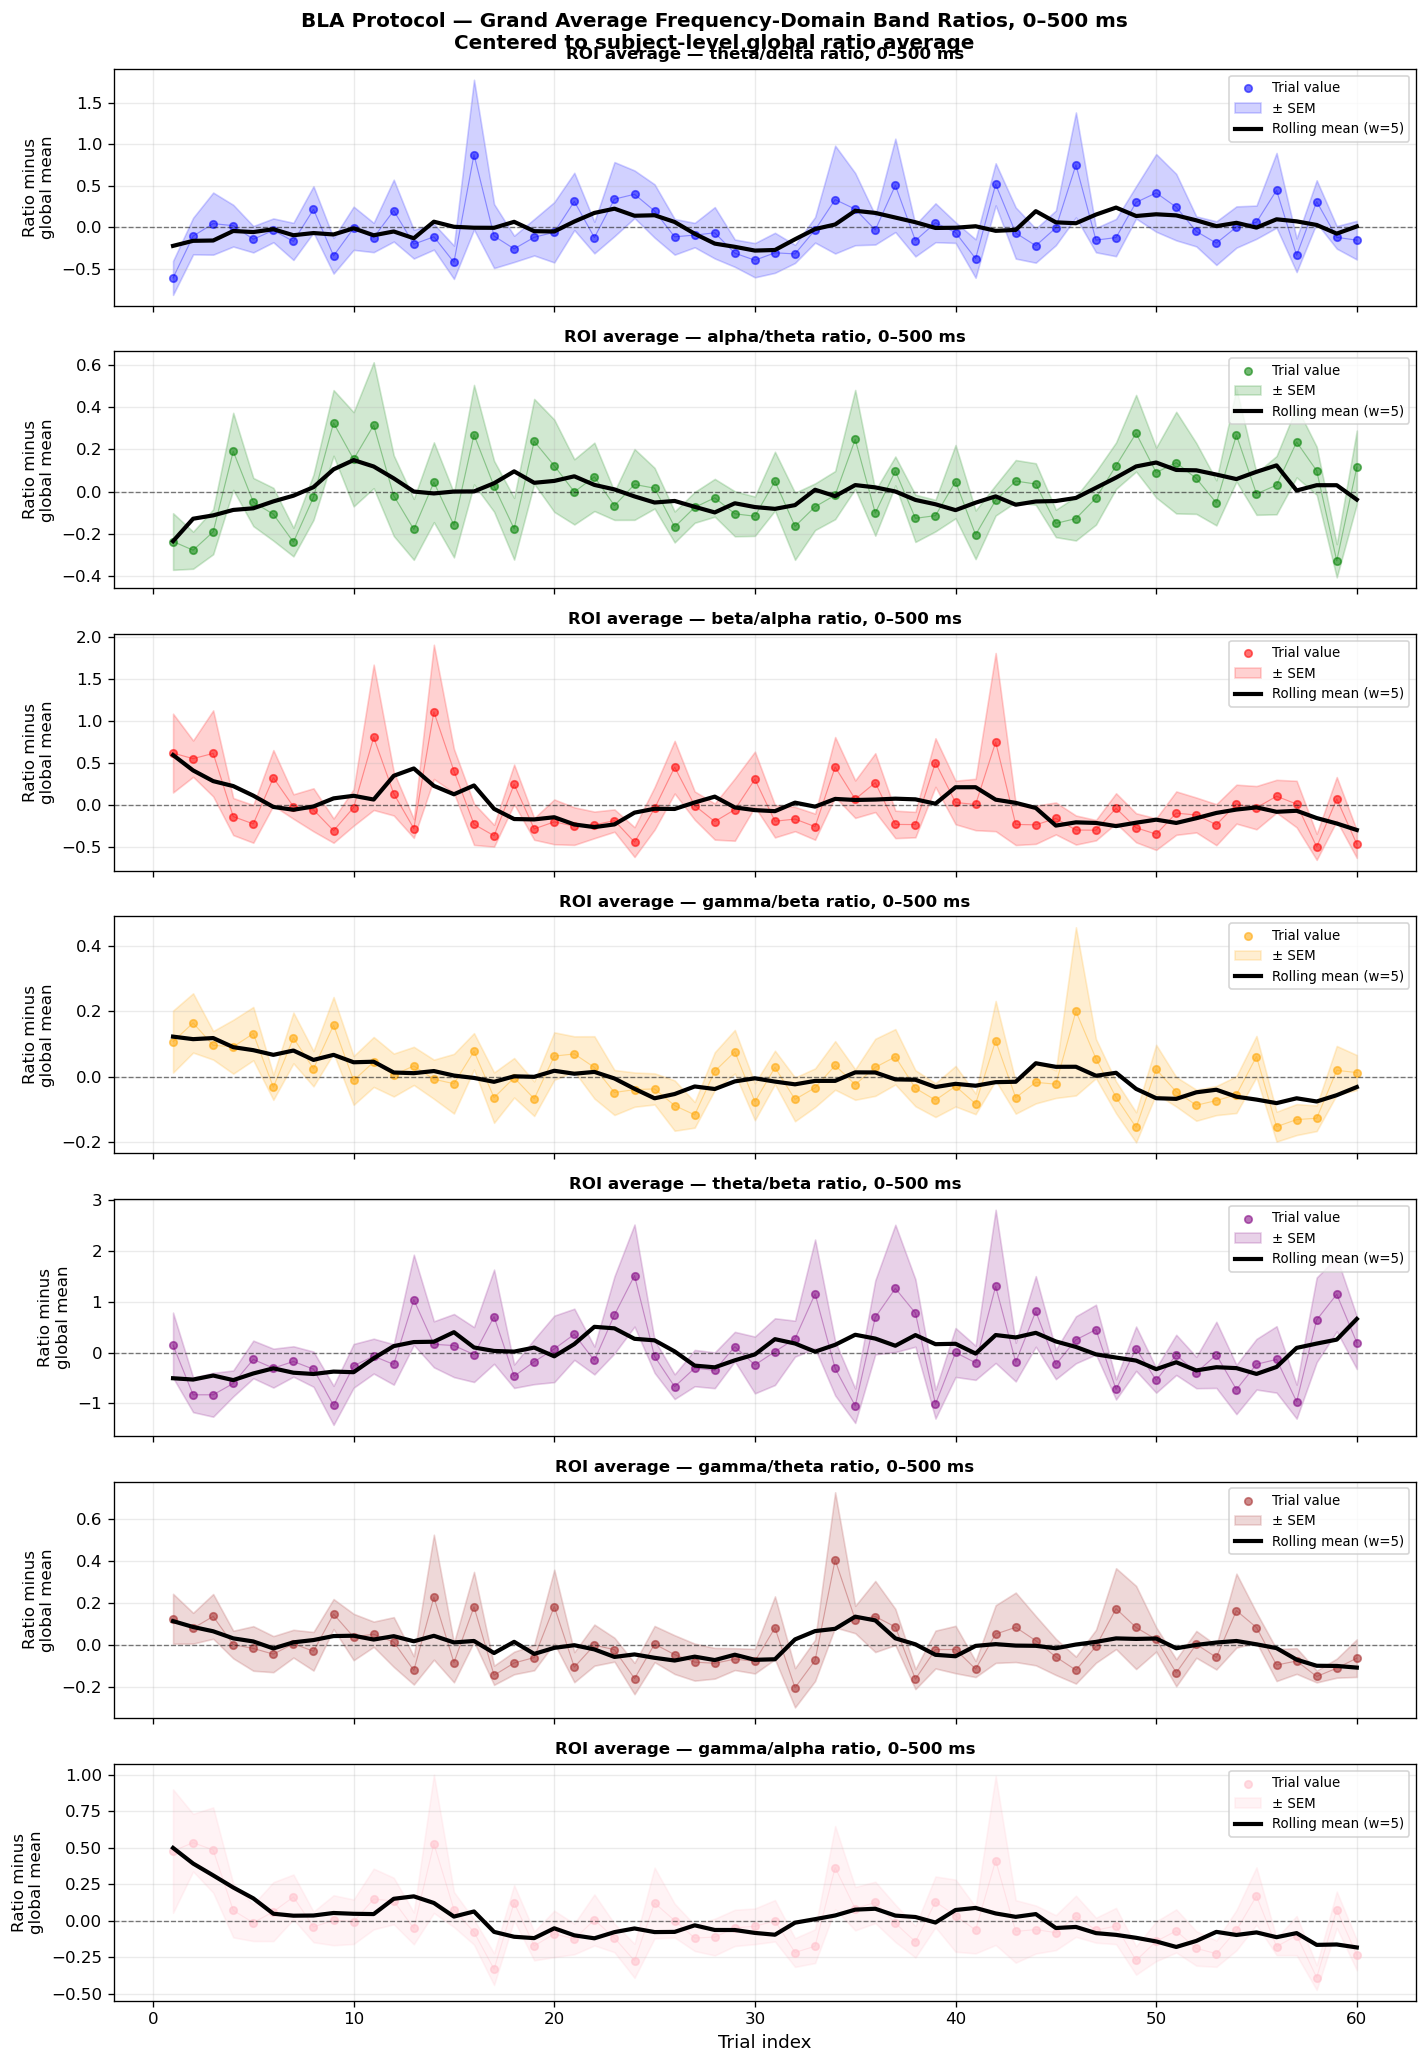

Figure saved: BLA_band_ratios_0_500_global_mean_centered.png


In [5]:

# ------------------------------------------------------------
# BAND RATIOS — 0–500 ms
# ------------------------------------------------------------

ratio_results_0_500 = compute_centered_band_ratios_for_window(
    window_name="0_500_ms",
    tmin=0.0,
    tmax=0.5
)

plot_centered_band_ratios(
    results=ratio_results_0_500,
    title_label="0–500 ms",
    save_filename="BLA_band_ratios_0_500_global_mean_centered.png"
)


500_1000_ms ratio subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


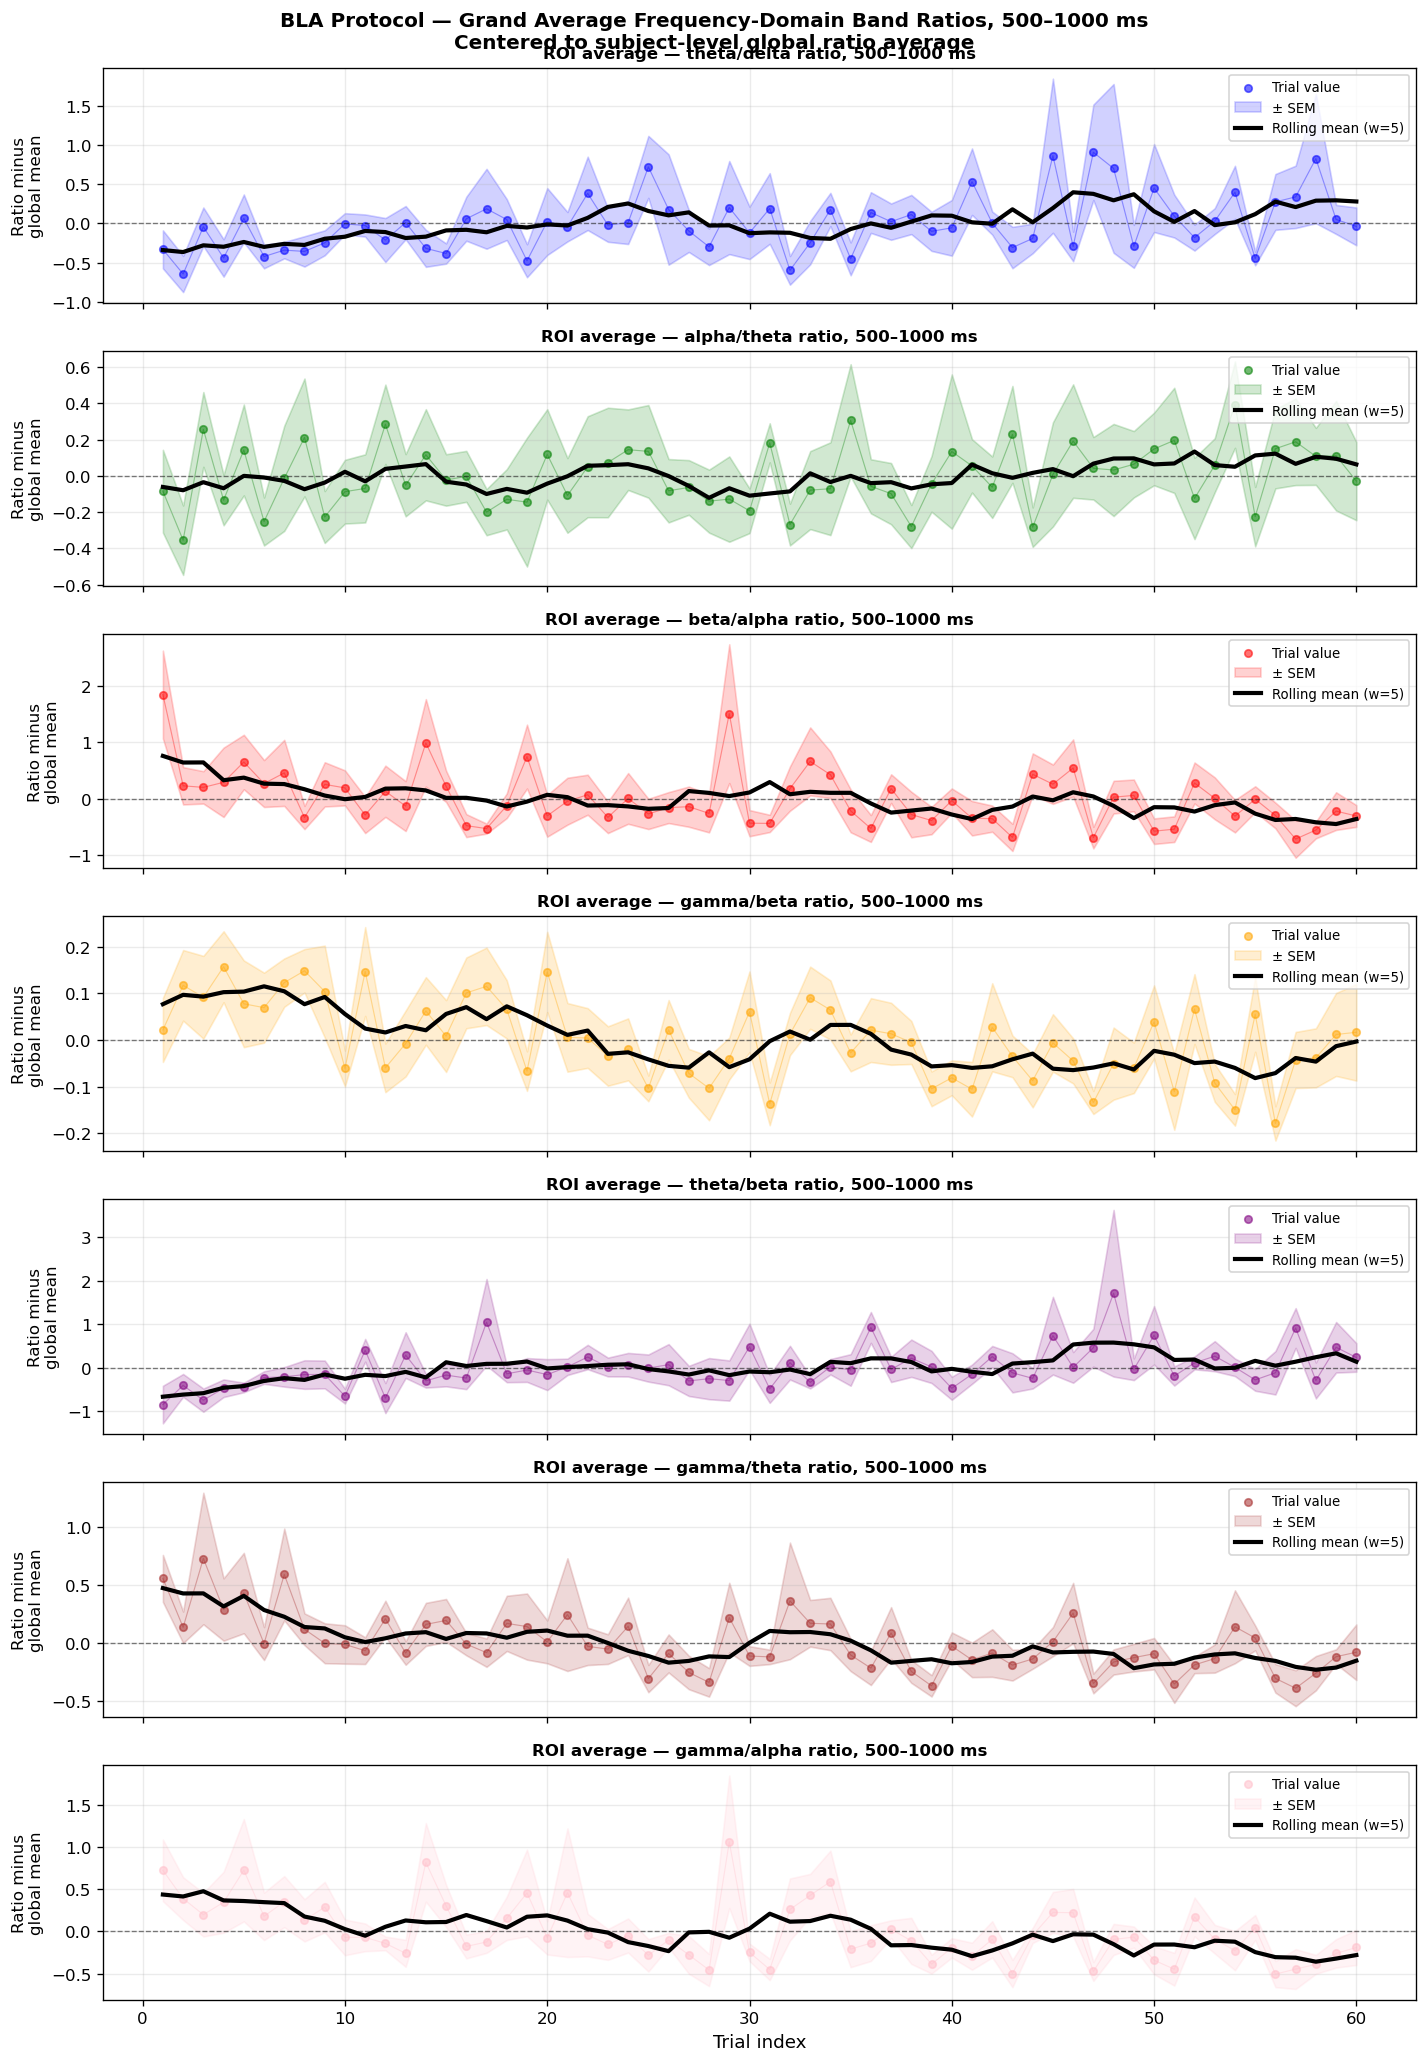

Figure saved: BLA_band_ratios_500_1000_global_mean_centered.png


In [6]:

# ------------------------------------------------------------
# BAND RATIOS — 500–1000 ms
# ------------------------------------------------------------

ratio_results_500_1000 = compute_centered_band_ratios_for_window(
    window_name="500_1000_ms",
    tmin=0.5,
    tmax=1.0
)

plot_centered_band_ratios(
    results=ratio_results_500_1000,
    title_label="500–1000 ms",
    save_filename="BLA_band_ratios_500_1000_global_mean_centered.png"
)


In [7]:

# ------------------------------------------------------------
# OPTIONAL: INSPECT ONE SUBJECT'S RAW AND CENTERED RATIOS
# ------------------------------------------------------------

# This lets you check the actual numbers for one subject.
example_subject = ratio_results_all_times["processed_subjects"][0]

print(f"Example subject: {example_subject}")

print("\nRaw ratio values, first few trials:")
display(ratio_results_all_times["all_ratio_pivots_raw"][example_subject].head())

print("\nGlobal ratio baselines subtracted:")
display(ratio_results_all_times["all_ratio_baseline_pivots"][example_subject])

print("\nCentered ratio values, first few trials:")
display(ratio_results_all_times["all_ratio_pivots_centered"][example_subject].head())


Example subject: 2

Raw ratio values, first few trials:


,theta/delta,alpha/theta,beta/alpha,gamma/beta,theta/beta,gamma/theta,gamma/alpha
trial,,,,,,,
0,0.798233,0.736149,1.816258,0.485016,0.747923,0.648484,0.880914
1,0.847560,0.615465,2.532493,0.627188,0.641576,0.977574,1.588349
2,1.335723,0.451257,2.098345,0.699494,1.056087,0.662346,1.467780
3,0.965094,0.492069,2.291989,0.744838,0.886669,0.840041,1.707160
4,0.801549,0.540471,2.556463,0.523366,0.723749,0.723132,1.337966



Global ratio baselines subtracted:


,theta/delta,alpha/theta,beta/alpha,gamma/beta,theta/beta,gamma/theta,gamma/alpha
0,0.969386,0.646109,1.564097,0.49472,1.092495,0.490443,0.798813



Centered ratio values, first few trials:


,theta/delta,alpha/theta,beta/alpha,gamma/beta,theta/beta,gamma/theta,gamma/alpha
trial,,,,,,,
0,-0.171152,0.090039,0.252161,-0.009704,-0.344572,0.158041,0.082102
1,-0.121826,-0.030644,0.968396,0.132468,-0.450919,0.487131,0.789537
2,0.366337,-0.194853,0.534248,0.204775,-0.036408,0.171902,0.668968
3,-0.004291,-0.154040,0.727892,0.250118,-0.205826,0.349597,0.908347
4,-0.167837,-0.105638,0.992366,0.028646,-0.368746,0.232689,0.539154
